# Hyperparameter Tuning — KNN & Decision Tree




## 0. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Dataset — Gaming: Predicting Player Churn



In [ ]:
n = 2000
sessions_per_week = np.random.poisson(5, n)
avg_session_minutes = np.random.normal(25, 12, n).clip(1, 120)
in_game_purchases = np.random.poisson(1.5, n)
player_level = np.random.randint(1, 100, n)
days_since_last_login = np.random.exponential(3, n).clip(0, 60)

churn_score = (
    -0.9 * sessions_per_week
    - 0.05 * avg_session_minutes
    - 1.0 * in_game_purchases
    - 0.035 * player_level
    + 0.7 * days_since_last_login
    + 4.4
)
churn_prob = 1 / (1 + np.exp(-churn_score))
churned = (np.random.rand(n) < churn_prob).astype(int)

df = pd.DataFrame({
    "SessionsPerWeek": sessions_per_week, "AvgSessionMinutes": avg_session_minutes,
    "InGamePurchases": in_game_purchases, "PlayerLevel": player_level,
    "DaysSinceLastLogin": days_since_last_login, "Churned": churned
})
print("Churn rate:", round(df["Churned"].mean(), 4))
df.head()

Churn rate: 0.237


,SessionsPerWeek,AvgSessionMinutes,InGamePurchases,PlayerLevel,DaysSinceLastLogin,Churned
0,5,45.239816,2,78,1.204830,0
1,4,16.718310,4,34,3.901709,0
2,4,34.291493,1,19,2.934847,0
3,5,33.507237,0,70,0.819435,0
4,5,1.000000,2,82,2.769664,0


In [ ]:
X = df.drop(columns=["Churned"])
y = df["Churned"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 1600  Test size: 400


---
## 2. Model 1 — K-Nearest Neighbors (KNN)





### 2.2 Baseline Model (default hyperparameters)

In [ ]:
knn_default = KNeighborsClassifier()  # all default hyperparameters: k=5, weights="uniform", metric="minkowski"
knn_default.fit(X_train_s, y_train)
baseline_knn_acc = accuracy_score(y_test, knn_default.predict(X_test_s))
print(f"Baseline KNN (default hyperparameters) Accuracy: {baseline_knn_acc:.4f}")

Baseline KNN (default hyperparameters) Accuracy: 0.8700


### 2.3 Manual Hyperparameter Sweep — Effect of `k`

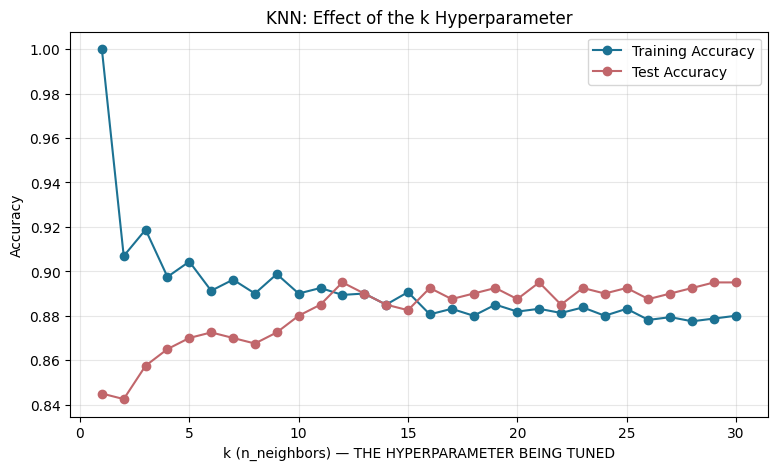

In [ ]:
k_values = range(1, 31)
train_acc, test_acc = [], []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train_s)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test_s)))

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), train_acc, marker="o", label="Training Accuracy", color="#1C7293")
plt.plot(list(k_values), test_acc, marker="o", label="Test Accuracy", color="#C1666B")
plt.xlabel("k (n_neighbors) — THE HYPERPARAMETER BEING TUNED")
plt.ylabel("Accuracy")
plt.title("KNN: Effect of the k Hyperparameter")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Observation:** Small `k` overfits (perfect training accuracy, worse test accuracy). Large `k`
underfits (both curves flatten and drop). The best `k` sits where test accuracy peaks.

### 2.4 Systematic Tuning — GridSearchCV

In [ ]:
knn_param_grid = {
    "n_neighbors": list(range(1, 31)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
knn_grid.fit(X_train_s, y_train)

print("Best KNN hyperparameters found:", knn_grid.best_params_)
print(f"Best cross-validation accuracy: {knn_grid.best_score_:.4f}")

knn_best = knn_grid.best_estimator_
tuned_knn_acc = accuracy_score(y_test, knn_best.predict(X_test_s))
print(f"\nTest Accuracy -> Default hyperparameters: {baseline_knn_acc:.4f}")
print(f"Test Accuracy -> Tuned hyperparameters:   {tuned_knn_acc:.4f}")

Best KNN hyperparameters found: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Best cross-validation accuracy: 0.8750

Test Accuracy -> Default hyperparameters: 0.8700
Test Accuracy -> Tuned hyperparameters:   0.8825



## 3. Model 2 — Decision Tree




### 3.2 Baseline Model (default hyperparameters)

In [ ]:
tree_default = DecisionTreeClassifier(random_state=42)  # max_depth=None (grows until pure) by default
tree_default.fit(X_train, y_train)
baseline_tree_acc = accuracy_score(y_test, tree_default.predict(X_test))
print(f"Baseline Decision Tree (default hyperparameters) Accuracy: {baseline_tree_acc:.4f}")
print(f"Tree depth grown: {tree_default.get_depth()}")

Baseline Decision Tree (default hyperparameters) Accuracy: 0.8325
Tree depth grown: 16


### 3.3 Manual Hyperparameter Sweep — Effect of `max_depth`

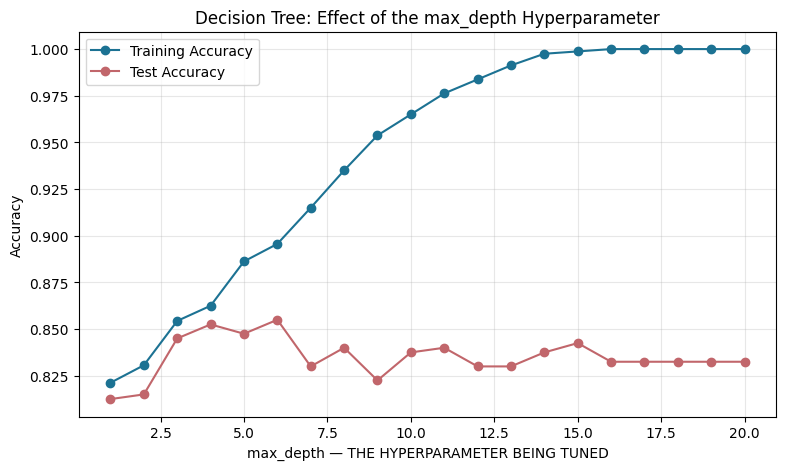

In [ ]:
depth_values = range(1, 21)
train_acc, test_acc = [], []

for d in depth_values:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(list(depth_values), train_acc, marker="o", label="Training Accuracy", color="#1C7293")
plt.plot(list(depth_values), test_acc, marker="o", label="Test Accuracy", color="#C1666B")
plt.xlabel("max_depth — THE HYPERPARAMETER BEING TUNED")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Effect of the max_depth Hyperparameter")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.4 Systematic Tuning — GridSearchCV

In [ ]:
tree_param_grid = {
    "max_depth": list(range(2, 15)),
    "min_samples_split": [2, 5, 10, 20, 40],
    "criterion": ["gini", "entropy"],
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=tree_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
tree_grid.fit(X_train, y_train)

print("Best Decision Tree hyperparameters found:", tree_grid.best_params_)
print(f"Best cross-validation accuracy: {tree_grid.best_score_:.4f}")

tree_best = tree_grid.best_estimator_
tuned_tree_acc = accuracy_score(y_test, tree_best.predict(X_test))
print(f"\nTest Accuracy -> Default hyperparameters: {baseline_tree_acc:.4f}")
print(f"Test Accuracy -> Tuned hyperparameters:   {tuned_tree_acc:.4f}")

Best Decision Tree hyperparameters found: {'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 40}
Best cross-validation accuracy: 0.8569

Test Accuracy -> Default hyperparameters: 0.8325
Test Accuracy -> Tuned hyperparameters:   0.8400


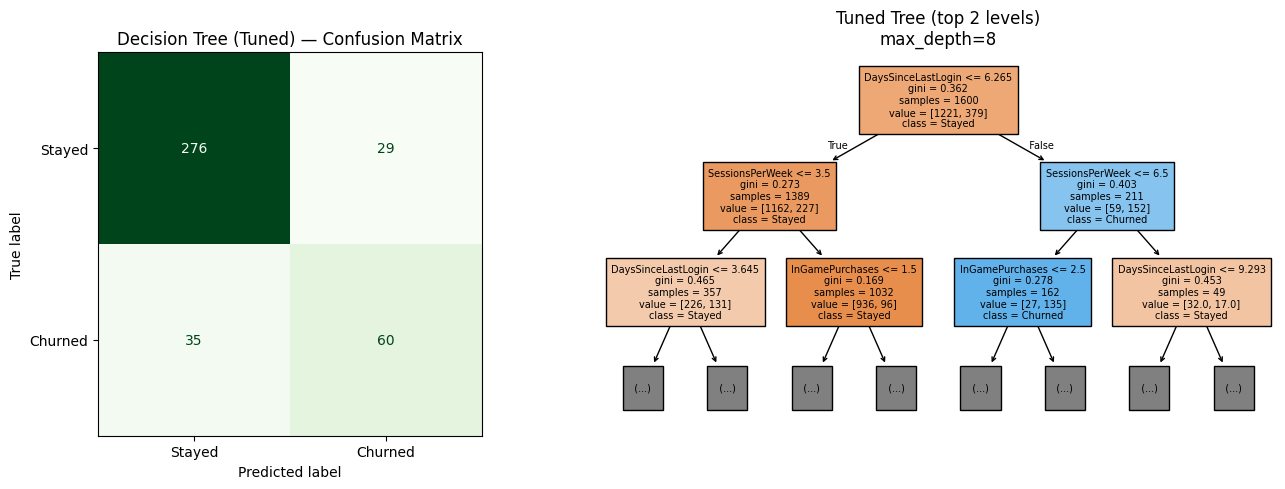

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, tree_best.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(ax=axes[0], cmap="Greens", colorbar=False)
axes[0].set_title("Decision Tree (Tuned) — Confusion Matrix")

plot_tree(tree_best, max_depth=2, feature_names=X.columns, class_names=["Stayed", "Churned"],
          filled=True, fontsize=7, ax=axes[1])
axes[1].set_title(f"Tuned Tree (top 2 levels)\nmax_depth={tree_grid.best_params_['max_depth']}")

plt.tight_layout()
plt.show()

---
## 4. Summary — Default vs. Tuned Hyperparameters


In [ ]:
summary = pd.DataFrame({
    "Model": ["KNN", "Decision Tree"],
    "Default Hyperparameters Accuracy": [baseline_knn_acc, baseline_tree_acc],
    "Tuned Hyperparameters Accuracy": [tuned_knn_acc, tuned_tree_acc],
    "Best Hyperparameters Found": [str(knn_grid.best_params_), str(tree_grid.best_params_)]
})
summary["Improvement"] = summary["Tuned Hyperparameters Accuracy"] - summary["Default Hyperparameters Accuracy"]
summary

,Model,Default Hyperparameters Accuracy,Tuned Hyperparameters Accuracy,Best Hyperparameters Found,Improvement
0,KNN,0.8700,0.8825,"{'metric': 'euclidean', 'n_neighbors': 15, 'we...",0.0125
1,Decision Tree,0.8325,0.8400,"{'criterion': 'gini', 'max_depth': 8, 'min_sam...",0.0075


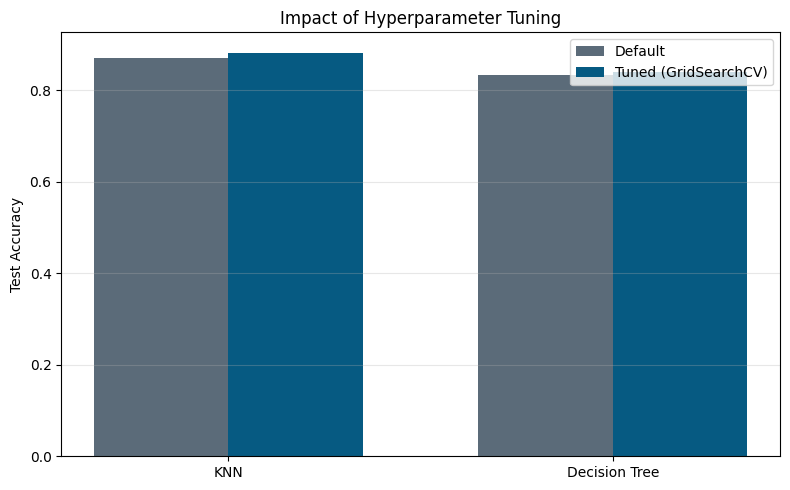

In [ ]:
x = np.arange(2)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, summary["Default Hyperparameters Accuracy"], width, label="Default", color="#5B6B79")
ax.bar(x + width/2, summary["Tuned Hyperparameters Accuracy"], width, label="Tuned (GridSearchCV)", color="#065A82")
ax.set_xticks(x)
ax.set_xticklabels(summary["Model"])
ax.set_ylabel("Test Accuracy")
ax.set_title("Impact of Hyperparameter Tuning")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()